In [1]:
import numpy as np
from pathlib import Path

embedding_dir = Path("../data/embeddings/codefuse-ai/F2LLM-v2-0.6B")

all_embeddings = []
embedding_indexer = []

for f in embedding_dir.iterdir():
    if f.stem.endswith("index"):
        continue
    embs = np.load(f)
    # only load newsgroups with approx. 500 messages
    if len(embs) < 400 or len(embs) > 600:
        continue
    all_embeddings.extend(embs)
    embedding_indexer += [f.stem] * len(embs)

len(embedding_indexer), len(all_embeddings)

(10066, 10066)

In [2]:
all_embeddings = np.array(all_embeddings)
all_embeddings.shape

(10066, 1024)

## Dimensionality reduction for plotting with UMAP
The UMAP algorithm reduces the high-dimensional document embeddings (1024 dimensions) to 2 dimensions, so we can plot them as x,y coordinates 

In [3]:
import umap

fit = umap.UMAP()
umap_2d_embeddings = fit.fit_transform(all_embeddings)
umap_2d_embeddings.shape

/home/tita/koding/usenet_no/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(10066, 2)

In [4]:
from collections import Counter

# We will use newsgroups and data source info in plot below
newsgroups_indexer = [file_stem.split("_")[0] for file_stem in embedding_indexer]
sources_indexer = [file_stem.split("_")[1] for file_stem in embedding_indexer]

print(f"Number of messages per source {Counter(sources_indexer)}")
print(f"Number of messages per newsgroup {Counter(newsgroups_indexer)}")

Number of messages per source Counter({'nwa': 5098, 'ia': 4968})
Number of messages per newsgroup Counter({'no.lisp': 983, 'no.mail.drift': 577, 'no.news.drift': 572, 'no.skole.diverse': 568, 'no.alt.marked.seksualitet': 550, 'no.folklore.overtro': 532, 'no.it.diverse': 527, 'no.video': 511, 'no.fag.sjukepleie': 500, 'no.kultur.folklore.diverse': 500, 'no.annonser.it.unix': 500, 'no.org.efn.diskusjon': 494, 'no.alt.irctreff': 493, 'no.psykolog': 486, 'no.hobby.diverse': 484, 'no.slekt.programmer': 459, 'no.annonser.it.nettverk': 450, 'no.uninett.diverse': 444, 'no.ai': 436})


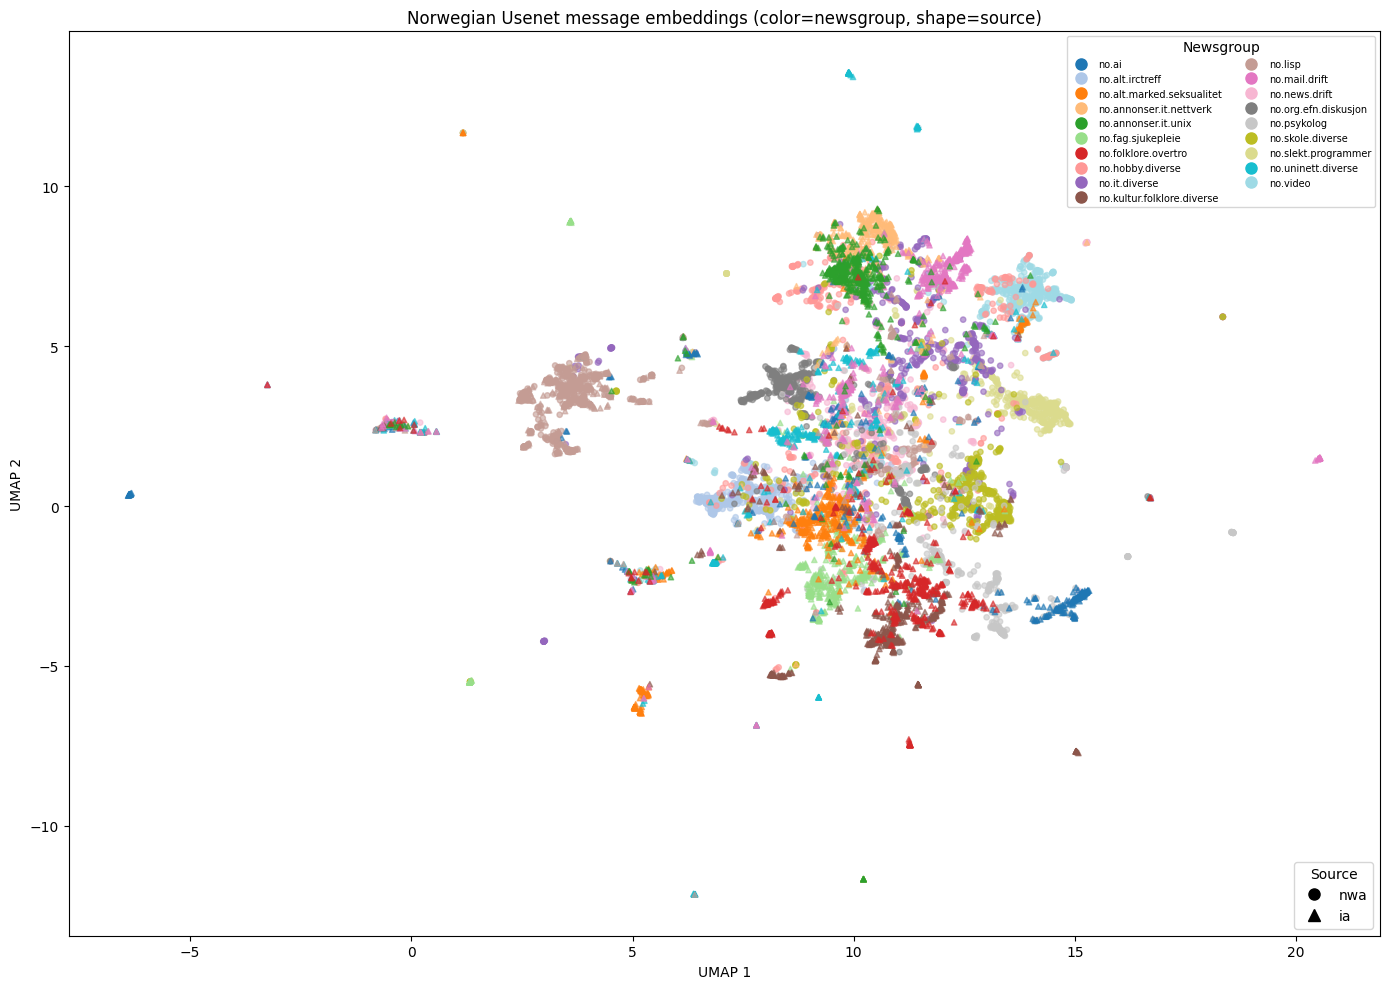

In [5]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

marker_map = {"nwa": "o", "ia": "^"}
unique_newsgroups = sorted(set(newsgroups_indexer))
cmap = plt.colormaps.get_cmap("tab20").resampled(len(unique_newsgroups))
color_map = {ng: cmap(i) for i, ng in enumerate(unique_newsgroups)}

colors = [color_map[ng] for ng in newsgroups_indexer]

fig, ax = plt.subplots(figsize=(14, 10))

# One loop over sources to separate by marker
for source, marker in marker_map.items():
    mask = np.array(sources_indexer) == source
    ax.scatter(
        umap_2d_embeddings[mask, 0],
        umap_2d_embeddings[mask, 1],
        c=[colors[i] for i, m in enumerate(mask) if m],
        marker=marker,
        s=15,
        alpha=0.6,
    )

# Legend for newsgroups (colors) — inside plot, upper right
color_handles = [
    mlines.Line2D(
        [],
        [],
        color=color_map[ng],
        marker="o",
        linestyle="None",
        markersize=8,
        label=ng,
    )
    for ng in unique_newsgroups
]
legend1 = ax.legend(
    handles=color_handles, title="Newsgroup", loc="upper right", fontsize=7, ncol=2
)
ax.add_artist(legend1)

# Legend for sources (markers) — inside plot, lower right
marker_handles = [
    mlines.Line2D(
        [],
        [],
        color="black",
        marker=marker_map[s],
        linestyle="None",
        markersize=8,
        label=s,
    )
    for s in marker_map
]
ax.legend(handles=marker_handles, title="Source", loc="lower right")

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Norwegian Usenet message embeddings (color=newsgroup, shape=source)")
plt.tight_layout()
plt.show()